In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
import matplotlib.ticker as ticker
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

In [2]:
##Functions to read cells and condensate datafiles and generate data structures

# headers_cells = ("date" + "\t" + "dataset" + "\t" + "z-slice" + "\t" + "cell_Id"
#            "\t" + "x" + "\t" + "y" + "\t" + "raw_exp" + "\t" + "cell_area" + "\t" + "background" +
#            "\t" + "nuc_intensity" + "\t" + "nuc_area" + "\n")

def read_cells_datafiles(path, genotype):
    
    dataset_date = path.split('/')[-1]
    datafolder = os.path.join(path)
    os.chdir(datafolder)
    print(os.getcwd())

    files_in_folder = os.listdir()

    cells_data_all = []
    cells_data_all.append(["date","dataset","z-slice","cell_Id",
                           "x", "y", "raw_exp", "cell_area", "background", 
                           "nuc_intensity", "nuc_area"])
    
    for element in files_in_folder:
        if dataset_date in element and genotype in element and element.endswith("_cells.txt"):
            file_to_open = element
            print("file to open:", file_to_open)

            with open(file_to_open, "r") as file:
                reader = csv.reader(file, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    cells_data_all.append([row[0], row[1], row[2], row[3], row[4], row[5], row[6],
                                         row[7], row[8], row[9], row[10]])

    return(cells_data_all)

# headers_condensates = ("date" + "\t" + "dataset" + "\t" + "cell_Id" +
#            "\t" + "condensateID" + "\t" + "x" + "\t" + "y" + 
#            "\t" + "raw_mass" + "\t" + "size" + "\t" + "ecc" + "\n")

def read_condensates_datafiles(path, genotype):
    
    dataset_date = path.split('/')[-1]
    datafolder = os.path.join(path)
    os.chdir(datafolder)
    print(os.getcwd())

    files_in_folder = os.listdir()

    condensates_data_all = []
    condensates_data_all.append(["date","dataset","cell_Id","condensateID",
                          "x", "y", "raw_mass","size", "ecc"])
    
    for element in files_in_folder:
        if dataset_date in element and genotype in element and element.endswith("_condensates.txt"):
            file_to_open = element
            print("file to open:", file_to_open)

            with open(file_to_open, "r") as file:
                reader = csv.reader(file, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    condensates_data_all.append([row[0], row[1], row[2], row[3], row[4], row[5], row[6],
                                         row[7], row[8]])

    return(condensates_data_all)

In [3]:
#Read calibration files

def read_calibration_files(calibration_path, protein):
    
    datafolder = os.path.join(calibration_path)
    os.chdir(datafolder)
    print(os.getcwd())

    files_in_folder = os.listdir()
    print(files_in_folder)
    
    calibration_data = []
    calibration_data.append(["date","protein","concentration","dataset","meanin", "meanout"])
    
    for element in files_in_folder:
        if protein in element and element.endswith("_calibration_output.txt"):
            file_to_open = element
            print("file to open:", file_to_open)
            
            with open(file_to_open, "r") as file:
                reader = csv.reader(file, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    calibration_data.append([row[0], row[1], row[2], row[3], row[5], row[7]])
    
    return(calibration_data)


def calibration_points(calibration_data):

    calibration_values = []
    for row_calibration in calibration_data[1:]:
    
        adjusted_brightness = float(row_calibration[4]) - float(row_calibration[5])
        calibration_values.append((int(row_calibration[2]), adjusted_brightness))
        print((int(row_calibration[2]), float(row_calibration[4])))

    #background_0nM = next(item[1] for item in calibration_values if item[0] == 0)
    
    return(calibration_values)


In [4]:
##Generate variables with cell and condensate data for further plotting

#data_analysis(data_cells, data_condensates)
#return()

def data_analysis(data_cells, data_condensates):

    # headers_cells = ("date" + "\t" + "dataset" + "\t" + "z-slice" + "\t" + "cell_Id"
    #            "\t" + "x" + "\t" + "y" + "\t" + "raw_exp" + "\t" + "cell_area" + "\t" + "background" +
    #            "\t" + "nuc_intensity" + "\t" + "nuc_area" + "\n")

    # headers_condensates = ("date" + "\t" + "dataset" + "\t" + "cell_Id" +
    #            "\t" + "condensateID" + "\t" + "x" + "\t" + "y" + 
    #            "\t" + "raw_mass" + "\t" + "size" + "\t" + "ecc" +"\n")
    
    max_condensate_size = 5000 #maximum condensate size (5000)
    min_condensate_size = 12 #minimum condensate size (12)
    
    dataset_all = []
    cell_ID_all = []
    
    mean_cell_intensity_all = [] #x-axis
    mean_nucleoplasm_intensity_all = [] #y-axis 3 

    density_condensates_in_cell_all = [] #y-axis 1
    fraction_of_cell_signal_in_condensates_all = [] #y-axis 2
    
    mean_intensity_of_condensates_in_cell_all = [] 
    mean_size_of_condensates_in_cell_all = []
    
    
    for row_cell in data_cells[1:]:
        
        #print(row_cell)
        dataset_all.append(row_cell[1])
        #print(row_cell[1])
        cell_ID_all.append(row_cell[3])

        #Cell stats
        background = float(row_cell[8]) #background
        mean_cell_intensity = float(row_cell[6]) / float(row_cell[7]) - background #background substracted
        mean_nucleoplasm_intensity = float(row_cell[9]) / float(row_cell[10]) - background #background substracted
        
        #Condensate stats for the current cell
        n_condensates_in_cell = 0
        sum_of_condensates_raw_mass = 0
        
        mean_intensity_of_condensates_in_cell = []
        size_of_condensates_in_cell = []

        
        for row_condensate in data_condensates[1:]:
            if row_cell[0] == row_condensate[0] and row_cell[1] == row_condensate[1] and row_cell[3] == row_condensate[2]:

    #             print("\ndate", row_cell[0], row_condensate[0])
    #             print("dataset", row_cell[1], row_condensate[1])
    #             print("cell_Id", row_cell[3], row_condensate[2])
    #             print("condensateID", row_condensate[3])
    
                #Discard large condensates, as they may be nucleolar accumulation of protein
                if float(row_condensate[7]) > max_condensate_size or float(row_condensate[7]) < min_condensate_size:
                    continue

                n_condensates_in_cell = n_condensates_in_cell + 1
                sum_of_condensates_raw_mass = sum_of_condensates_raw_mass + float(row_condensate[6])
                
                mean_intensity_of_condensates = float(row_condensate[6])/float(row_condensate[7]) - background #background substracted
                mean_intensity_of_condensates_in_cell.append(mean_intensity_of_condensates)
                
                size_of_condensates_in_cell.append(float(row_condensate[7]))
                
        mean_cell_intensity_all.append(mean_cell_intensity)       

        density_condensates_in_cell = n_condensates_in_cell / float(row_cell[7])
        density_condensates_in_cell_all.append(density_condensates_in_cell) 

        fraction_of_cell_signal_in_condensates = sum_of_condensates_raw_mass / float(row_cell[6])
        fraction_of_cell_signal_in_condensates_all.append(fraction_of_cell_signal_in_condensates)

        mean_nucleoplasm_intensity_all.append(mean_nucleoplasm_intensity)
        
        mean_intensity_of_condensates_in_cell_all.append(np.mean(mean_intensity_of_condensates_in_cell) if len(mean_intensity_of_condensates_in_cell) != 0 else 0)
#         print('mean_intensity_of_condensates_in_cell', mean_intensity_of_condensates_in_cell)
#         print('np.mean(mean_intensity_of_condensates_in_cell)', np.mean(mean_intensity_of_condensates_in_cell))
#         print('mean_intensity_of_condensates_in_cell_all', mean_intensity_of_condensates_in_cell_all)
        
        mean_size_of_condensates_in_cell_all.append(np.mean(size_of_condensates_in_cell) if len(size_of_condensates_in_cell) != 0 else 0)
        
        if fraction_of_cell_signal_in_condensates > 0.18 and mean_cell_intensity < 30:
            print('date', row_cell[0])
            print('dataset', row_cell[1])
            print('cellID', row_cell[3])
            print('mean_cell_intensity', mean_cell_intensity)
            print('sum_of_condensates_raw_mass', sum_of_condensates_raw_mass)
            print('raw_exp', float(row_cell[6]))
            print('fraction_of_cell_signal_in_condensates', fraction_of_cell_signal_in_condensates)

        
    return [mean_cell_intensity_all,
            mean_nucleoplasm_intensity_all,
            density_condensates_in_cell_all,
            fraction_of_cell_signal_in_condensates_all,
            mean_intensity_of_condensates_in_cell_all,
            mean_size_of_condensates_in_cell_all,
            dataset_all,
            cell_ID_all]


E:\Augusto\Images\SoRa\CalibrationFiles
['02042024-SoRa-mCherry-SPARKOFF_calibration_output.txt', '23042024-SoRa-EGFP_calibration_output.txt']
file to open: 23042024-SoRa-EGFP_calibration_output.txt
(500, 187.810794)
(500, 184.359705)
(500, 178.42146)
(500, 179.752764)
(400, 159.895388)
(400, 155.856755)
(400, 158.812439)
(400, 156.342875)
(300, 138.208262)
(300, 137.549785)
(300, 136.926372)
(300, 136.870299)
(200, 127.469298)
(200, 127.17959)
(200, 127.213973)
(200, 127.048205)
(100, 113.451155)
(100, 113.088269)
(100, 113.299289)
(100, 113.22194)
(50, 106.880812)
(50, 107.066238)
(50, 107.330715)
(50, 107.280442)
(25, 104.981756)
(25, 104.75099)
(25, 104.760688)
(25, 104.81444)
(0, 102.639774)
(0, 102.606704)
(0, 102.791845)
(0, 102.725477)
y = 27.57x + 36.19


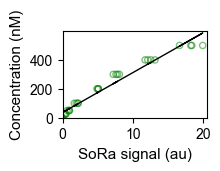

In [24]:
###Obtain linear regression equations from 
###This piece of code must be replaced for a better way to obtain calibration values

###Normalize fluorescence intensity to concentration values
#mEGFP

########
####### mEGFP Values
#calibration_data.append(["date","protein","concentration","dataset","mean"])

calibration_path = 'E:/Augusto/Images/SoRa/CalibrationFiles/'
protein = 'EGFP'

calibration_data_EGFP = read_calibration_files(calibration_path, protein)
EGFP_values = calibration_points(calibration_data_EGFP)

# Performing linear regression
y_EGFP_concentration = np.array([item[0] for item in EGFP_values])
x_EGFP_fluorescence = np.array([item[1] for item in EGFP_values])

slope_EGFP, intercept_EGFP = np.polyfit(x_EGFP_fluorescence, y_EGFP_concentration, 1)
#intercept_mEGFP = 0
# Regression line equation
equation_EGFP = f"y = {slope_EGFP:.2f}x + {intercept_EGFP:.2f}"

print(equation_EGFP)

#Print for publication

fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.6))

# Plotting the data points and regression line
ax.scatter(x_EGFP_fluorescence, y_EGFP_concentration, facecolor='none',  edgecolor='green',
          marker = 'o', s = 20, alpha = 0.5)

ax.plot(x_EGFP_fluorescence, slope_EGFP * x_EGFP_fluorescence + intercept_EGFP, linewidth=1, color='black', label = equation_EGFP)

# Adding labels and title
# Adding labels and title
ax.set_xlabel('SoRa signal (au)', fontsize=11, fontname="Arial")
ax.set_ylabel('Concentration (nM)', fontsize=11, fontname="Arial")
#plt.title('EGFP\ncalibration of molarity and fluorescence')
ax.set_ylim(0, 600)
ax.set_xlim(0, 20.5)
ax.set_xticks([0, 10, 20])
ax.set_yticks([0, 200, 400])

ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Show the plot
#plt.grid()
fig.tight_layout()
plt.show()

#Figure outputs
output_path = "D:/Augusto/PythonCode/FigureS1/"
# Save as PNG, 300 dpi is publication quality
image_file_name = output_path + "mEGFP_SoRa_calibration_molarity.png"
fig.savefig(image_file_name, bbox_inches='tight', dpi=300, format="png")
plt.close(fig)



In [6]:
#Converts fluorescence values to molarity.
#The slope and intercept values from a linear regression fit must be provided

def fluorescence2concentration(fluorescence_list, slope, intercept):
    
    concentration_list_negative = [round(slope * element + intercept) for element in fluorescence_list]
    concentration_list = [element if element >= 0 else 0 for element in concentration_list_negative]
    
    return(concentration_list)

# fluorescence_list_test = [50, 100, 108, 110, 150, 200, 260]
# print(fluorescence2concentration(fluorescence_list_test, slope_mEGFP, intercept_mEGFP))

In [7]:
###Read mEGFP-Nup98-KDM5A-SoRa

path_mEGFP_Nup98KDM5A_SoRa = 'E:/Augusto/Images/SoRa/27112023-SoRa/analysis_27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa/'
genotype_mEGFP_Nup98KDM5A_SoRa = 'mEGFP-Nup98-KDM5A-SoRa'

data_cells_mEGFP_Nup98KDM5A_SoRa = read_cells_datafiles(path_mEGFP_Nup98KDM5A_SoRa, genotype_mEGFP_Nup98KDM5A_SoRa)
data_condensates_mEGFP_Nup98KDM5A_SoRa = read_condensates_datafiles(path_mEGFP_Nup98KDM5A_SoRa, genotype_mEGFP_Nup98KDM5A_SoRa)

analysis_mEGFP_Nup98KDM5A_SoRa = data_analysis(data_cells_mEGFP_Nup98KDM5A_SoRa, data_condensates_mEGFP_Nup98KDM5A_SoRa)

mean_cell_intensity_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[0]
mean_nucleoplasm_intensity_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[1]
density_condensates_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[2]
fraction_of_cell_signal_in_condensates_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[3]
mean_intensity_of_condensates_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[4]
mean_size_of_condensates_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[5]

dataset_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[6]
cell_ID_mEGFP_Nup98KDM5A_SoRa = analysis_mEGFP_Nup98KDM5A_SoRa[7]

E:\Augusto\Images\SoRa\27112023-SoRa\analysis_27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_10_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_12_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_13_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_14_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_15_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_16_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_17_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_18_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_19_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_1_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_20_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_21_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_22_cells.txt
file to open: 27112023-SoRa_mEGFP-Nup98-KDM5A-SoRa_23_cells.txt
file to open: 27112023

In [8]:
###Read mCherry-Nup98-HoxA9-SoRa

# path_mCherry_Nup98HoxA9_SoRa = 'E:/Augusto/Images/SoRa/18012024-SoRa/analysis_18012024-SoRa_mCherry-Nup98-HoxA9-SoRa/'
# genotype_mCherry_Nup98HoxA9_SoRa = 'mCherry-Nup98-HoxA9-SoRa'

# data_cells_mCherry_Nup98HoxA9_SoRa = read_cells_datafiles(path_mCherry_Nup98HoxA9_SoRa, genotype_mCherry_Nup98HoxA9_SoRa)
# data_condensates_mCherry_Nup98HoxA9_SoRa = read_condensates_datafiles(path_mCherry_Nup98HoxA9_SoRa, genotype_mCherry_Nup98HoxA9_SoRa)

# analysis_mCherry_Nup98HoxA9_SoRa = data_analysis(data_cells_mCherry_Nup98HoxA9_SoRa, data_condensates_mCherry_Nup98HoxA9_SoRa)

# mean_cell_intensity_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[0]
# mean_nucleoplasm_intensity_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[1]
# density_condensates_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[2]
# fraction_of_cell_signal_in_condensates_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[3]
# mean_intensity_of_condensates_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[4]
# mean_size_of_condensates_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[5]

# dataset_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[6]
# cell_ID_mCherry_Nup98HoxA9_SoRa = analysis_mCherry_Nup98HoxA9_SoRa[7]

In [9]:
###Read mEGFP-Nup98-KDM5A-SoRa

path_sfGFP_Nup98KDM5A_SoRa = 'E:/Augusto/Images/SoRa/13032024-SoRa-Tianhong/analysis_13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A/'
genotype_sfGFP_Nup98KDM5A_SoRa = 'sfGFP-Nup98-KDM5A'

data_cells_sfGFP_Nup98KDM5A_SoRa = read_cells_datafiles(path_sfGFP_Nup98KDM5A_SoRa, genotype_sfGFP_Nup98KDM5A_SoRa)
data_condensates_sfGFP_Nup98KDM5A_SoRa = read_condensates_datafiles(path_sfGFP_Nup98KDM5A_SoRa, genotype_sfGFP_Nup98KDM5A_SoRa)

analysis_sfGFP_Nup98KDM5A_SoRa = data_analysis(data_cells_sfGFP_Nup98KDM5A_SoRa, data_condensates_sfGFP_Nup98KDM5A_SoRa)

mean_cell_intensity_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[0]
mean_nucleoplasm_intensity_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[1]
density_condensates_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[2]
fraction_of_cell_signal_in_condensates_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[3]
mean_intensity_of_condensates_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[4]
mean_size_of_condensates_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[5]

dataset_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[6]
cell_ID_sfGFP_Nup98KDM5A_SoRa = analysis_sfGFP_Nup98KDM5A_SoRa[7]

E:\Augusto\Images\SoRa\13032024-SoRa-Tianhong\analysis_13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_10_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_11_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_12_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_13_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_14_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_15_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_16_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_17_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_18_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_19_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_1_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_20_cells.txt
file to open: 13032024-SoRa-Tianhong_sfGFP-Nup98-KDM5A_21_cells.txt
file to open: 1303202

In [10]:
###Read Nup98-KDM5A-mEGFP-SoRa

path_Nup98KDM5A_mEGFP_SoRa = 'E:/Augusto/Images/SoRa/03042024-SoRa-Tianhong/analysis_03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa/'
genotype_Nup98KDM5A_mEGFP_SoRa = 'Nup98-KDM5A-mEGFP-SoRa'


data_cells_Nup98KDM5A_mEGFP_SoRa = read_cells_datafiles(path_Nup98KDM5A_mEGFP_SoRa, genotype_Nup98KDM5A_mEGFP_SoRa)
data_condensates_Nup98KDM5A_mEGFP_SoRa = read_condensates_datafiles(path_Nup98KDM5A_mEGFP_SoRa, genotype_Nup98KDM5A_mEGFP_SoRa)

analysis_Nup98KDM5A_mEGFP_SoRa = data_analysis(data_cells_Nup98KDM5A_mEGFP_SoRa, data_condensates_Nup98KDM5A_mEGFP_SoRa)

mean_cell_intensity_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[0]
mean_nucleoplasm_intensity_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[1]
density_condensates_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[2]
fraction_of_cell_signal_in_condensates_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[3]
mean_intensity_of_condensates_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[4]
mean_size_of_condensates_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[5]

dataset_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[6]
cell_ID_Nup98KDM5A_mEGFP_SoRa = analysis_Nup98KDM5A_mEGFP_SoRa[7]

E:\Augusto\Images\SoRa\03042024-SoRa-Tianhong\analysis_03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_10_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_11_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_12_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_13_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_14_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_15_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_16_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_17_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_18_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_19_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_1_cells.txt
file to open: 03042024-SoRa-Tianhong_Nup98-KDM5A-mEGFP-SoRa_20_cells.txt
file to open: 03042024-S

In [11]:
# Convert cell and nucleoplasm intensity into concentration values
##
mean_cell_concentration_mEGFP_Nup98KDM5A_SoRa = np.array(fluorescence2concentration(mean_cell_intensity_mEGFP_Nup98KDM5A_SoRa, slope_EGFP, intercept_EGFP))
mean_cell_concentration_Nup98KDM5A_mEGFP_SoRa = np.array(fluorescence2concentration(mean_cell_intensity_Nup98KDM5A_mEGFP_SoRa, slope_EGFP, intercept_EGFP))


##
mean_nucleoplasm_concentration_mEGFP_Nup98KDM5A_SoRa = np.array(fluorescence2concentration(mean_nucleoplasm_intensity_mEGFP_Nup98KDM5A_SoRa, slope_EGFP, intercept_EGFP))
mean_nucleoplasm_concentration_Nup98KDM5A_mEGFP_SoRa = np.array(fluorescence2concentration(mean_nucleoplasm_intensity_Nup98KDM5A_mEGFP_SoRa, slope_EGFP, intercept_EGFP))


In [12]:
#Count all non-zero values of datasets (for log)
#Color palettes
#https://colorany.com/color-palettes/colorblind-friendly-color-palettes/

Nup98KDM5A_mEGFP_color = '#6AB04C'
mEGFP_Nup98KDM5A_color = '#C1272D'

#Labels
#n for each dataset
n_Nup98KDM5A_mEGFP = np.count_nonzero(mean_cell_intensity_Nup98KDM5A_mEGFP_SoRa)
n_mEGFP_Nup98KDM5A = np.count_nonzero(mean_cell_intensity_mEGFP_Nup98KDM5A_SoRa)

#label
label_Nup98KDM5A_mEGFP = "NUP98-KDM5A-mEGFP, n = " + str(n_Nup98KDM5A_mEGFP)
label_mEGFP_Nup98KDM5A = "mEGFP-NUP98-KDM5A, n = " + str(n_mEGFP_Nup98KDM5A)

#legend handles
legend_handles = [
    plt.Line2D([], [], marker='o', markerfacecolor=Nup98KDM5A_mEGFP_color, color='None', linestyle='None', label=label_Nup98KDM5A_mEGFP),
]

print(label_Nup98KDM5A_mEGFP)
print(label_mEGFP_Nup98KDM5A)


NUP98-KDM5A-mEGFP, n = 63
mEGFP-NUP98-KDM5A, n = 112


In [13]:
#Figure outputs

output_path = "D:/Augusto/PythonCode/FigureS1/"

In [14]:
#Metadata
#<Pixels BigEndian="false" DimensionOrder="XYCZT" ID="Pixels:0" Interleaved="false" PhysicalSizeX="0.0262" PhysicalSizeXUnit="µm" PhysicalSizeY="0.0262" PhysicalSizeYUnit="µm" PhysicalSizeZ="0.2599999999999998" PhysicalSizeZUnit="µm" SignificantBits="16" SizeC="2" SizeT="1" SizeX="2300" SizeY="2100" SizeZ="31" TimeIncrement="300000.0" TimeIncrementUnit="ms" Type="uint16">
#pixel size "0.0262 um"
pixel_size_um = 0.0262

C:\Programs\Anaconda3\envs\spotcell_segmentation\lib\site-packages\ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log10
  from ipykernel import kernelapp as app
C:\Programs\Anaconda3\envs\spotcell_segmentation\lib\site-packages\ipykernel_launcher.py:50: RuntimeWarning: divide by zero encountered in log10


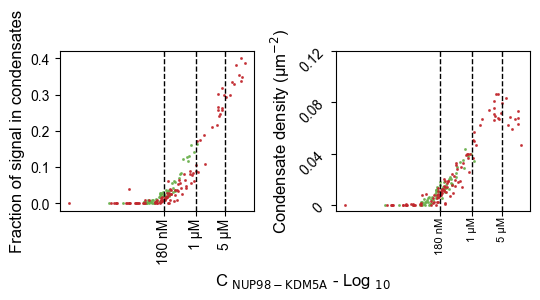

In [26]:
###Fraction of signal in condensates

#Count values that are not 0

###Fraction of signal 
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5))

fig.text(0.4, 0, 'C $_{\mathrm{NUP98-KDM5A}}$ - Log $_{\mathrm{10}}$', va='center', rotation='horizontal', fontsize=12, fontname="Arial")


sc1 = ax[0].scatter(np.log10(mean_cell_concentration_Nup98KDM5A_mEGFP_SoRa), fraction_of_cell_signal_in_condensates_Nup98KDM5A_mEGFP_SoRa,
                 marker = ".", c = Nup98KDM5A_mEGFP_color, s = 5,
                 alpha = 0.8, label='NUP98-KDM5A-mEGFP')

sc2 = ax[0].scatter(np.log10(mean_cell_concentration_mEGFP_Nup98KDM5A_SoRa), fraction_of_cell_signal_in_condensates_mEGFP_Nup98KDM5A_SoRa,
                 marker = ".", c = mEGFP_Nup98KDM5A_color, s = 5,
                 alpha = 0.8, label='mEGFP-NUP98-KDM5A')

ax[0].set_ylabel('Fraction of signal in condensates', fontsize=12, fontname="Arial")
ax[0].tick_params(axis='x', labelsize=10)
ax[0].tick_params(axis='y', labelsize=10)

xt1 = np.log10(180)
xt2 = np.log10(1000)
xt3 = np.log10(5000)
ax[0].set_xticks([xt1, xt2, xt3])
ax[0].set_xticklabels([])

ax[0].text(np.log10(180), -0.04, "180 nM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[0].text(np.log10(1000), -0.04, "1 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[0].text(np.log10(5000), -0.04, "5 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[0].axvline(x = np.log10(180), color='black', linestyle='--', linewidth=1, label='180 nM')
ax[0].axvline(x = np.log10(1000), color='black', linestyle='--', linewidth=1, label='1000 nM')
ax[0].axvline(x = np.log10(5000), color='black', linestyle='--', linewidth=1, label='5000 nM')

###Fraction of signal in condensates

#Count values that are not 0

sc1 = ax[1].scatter(np.log10(mean_cell_concentration_Nup98KDM5A_mEGFP_SoRa), np.array(density_condensates_Nup98KDM5A_mEGFP_SoRa) * 1 / pixel_size_um,
                 marker = ".", c = Nup98KDM5A_mEGFP_color, s = 5,
                 alpha = 0.8, label='NUP98-KDM5A-mEGFP')

sc2 = ax[1].scatter(np.log10(mean_cell_concentration_mEGFP_Nup98KDM5A_SoRa), np.array(density_condensates_mEGFP_Nup98KDM5A_SoRa) * 1 / pixel_size_um,
                 marker = ".", c = mEGFP_Nup98KDM5A_color, s = 5,
                 alpha = 0.8, label='mEGFP-NUP98-KDM5A')

ax[1].set_ylabel('Condensate density (µm$^{-2}$)', fontsize=12, fontname="Arial")
ax[1].tick_params(axis='x', labelsize=10)
ax[1].tick_params(axis='y', labelsize=10)

ax[1].set_yticks([0, 0.04, 0.08, 0.12])
ax[1].set_yticklabels([0, 0.04, 0.08, 0.12], rotation=45)
# ax[1].set_xticks([0, 2, 4])

xt1 = np.log10(180)
xt2 = np.log10(1000)
xt3 = np.log10(5000)
ax[1].set_xticks([xt1, xt2, xt3])
ax[1].set_xticklabels([])

ax[1].text(np.log10(180), -0.009, "180 nM", color="black", rotation=90,
        ha="center", va="top", fontsize=8, fontweight="normal")

ax[1].text(np.log10(1000), -0.009, "1 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=8, fontweight="normal")

ax[1].text(np.log10(5000), -0.009, "5 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=8, fontweight="normal")

ax[1].axvline(x = np.log10(180), color='black', linestyle='--', linewidth=1, label='180 nM')
ax[1].axvline(x = np.log10(1000), color='black', linestyle='--', linewidth=1, label='1000 nM')
ax[1].axvline(x = np.log10(5000), color='black', linestyle='--', linewidth=1, label='5000 nM')


# Show the plot
fig.tight_layout()
plt.show()

# Save as PNG, 300 dpi is publication quality
image_file_name = output_path + "Fraction_and_density_supplemental.png"
fig.savefig(image_file_name, bbox_inches='tight', pad_inches=0.1, dpi=300, format="png")
plt.close(fig)